In [ ]:
import warnings
warnings.filterwarnings("ignore")
from ucimlrepo import fetch_ucirepo
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets
X = X.dropna()
#X = X.drop(columns=['workclass', 'occupation', 'native-country'])

print(X.head())

from sklearn.preprocessing import LabelEncoder

categorical = ['workclass', 'education', 'marital-status', 'occupation',
               'relationship', 'race', 'sex', 'native-country']
label_encoder = LabelEncoder()
for col in categorical:
    if col in X.columns:
        X[col] = label_encoder.fit_transform(X[col])
print(X.head())

y = adult.data.targets['income']
y = pd.Series(y, name="target")
y = y.replace({'<=50K': 0, '<=50K.': 0, '>50K': 1, '>50K.': 1})

df_combined = pd.concat([X, y], axis=1)
df_combined = df_combined.dropna()
print(df_combined)

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country  
0          2174             0              40  United-States  
1             0             0              13  United-St

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, KFold
from itertools import combinations
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

class IMVEvaluator:
    def __init__(self, data, outcome_variable, optional_explanatory_variables, model_creator, split_method, n_splits, prop_test, model_type, all_combinations_imv=None, random_seed=42):
        self.data = data
        self.outcome_variable = outcome_variable
        self.optional_explanatory_variables = optional_explanatory_variables
        self.model_creator = model_creator
        self.split_method = split_method
        self.n_splits = n_splits
        self.prop_test = prop_test
        self.model_type = model_type
        self.random_seed = random_seed  # Set the random seed
        self.data['constant'] = 1  # Add a constant column for modeling
        self.all_combinations_imv = all_combinations_imv if all_combinations_imv is not None else {}

    @staticmethod
    def ll(x, p):
        epsilon = 1e-4
        z = (np.log(p + epsilon) * x) + (np.log(1 - p + epsilon) * (1 - x))
        return np.exp(np.sum(z) / len(z))

    @staticmethod
    def minimize_me(p, a):
        return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

    @classmethod
    def get_w(cls, a, guess=0.5, bounds=[(0.5, 0.999)]):
        res = minimize(cls.minimize_me, guess, args=(a,), options={'ftol': 0, 'gtol': 1e-09}, method='L-BFGS-B', bounds=bounds)
        return res.x[0]

    @classmethod
    def calculate_imv(cls, y_basic, y_enhanced, y):
        ll_basic = cls.ll(y, y_basic)
        ll_enhanced = cls.ll(y, y_enhanced)
        w0 = cls.get_w(ll_basic)
        w1 = cls.get_w(ll_enhanced)
        return (w1 - w0) / w0

    def calculate_imv_score(self, model_basic, model_enhanced, X_basic, X_enhanced, y):
        if self.model_type == 'classification':
            pred_basic = model_basic.predict_proba(X_basic)[:, 1]
            pred_enhanced = model_enhanced.predict_proba(X_enhanced)[:, 1]
        elif self.model_type == 'regression':
            pred_basic = model_basic.predict(X_basic)
            pred_enhanced = model_enhanced.predict(X_enhanced)
        else:
            raise ValueError("model_type must be 'classification' or 'regression'")
        return self.calculate_imv(pred_basic, pred_enhanced, y)

    def compute_imv_method(self, combination):
        X = self.data[list(combination) + ['constant']]
        y = self.data[self.outcome_variable]
        imv_scores = []
        fold_imv_scores = []

        if self.split_method == 'train_test_split':
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.prop_test, random_state=self.random_seed)
            model_basic = self.model_creator()
            model_enhanced = self.model_creator()
            model_basic.fit(X_train[['constant']], y_train)
            model_enhanced.fit(X_train, y_train)
            imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
            imv_scores.append(imv_score)
            fold_imv_scores.append(imv_score)
        elif self.split_method == 'kfold':
            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_seed)
            for train_index, test_index in kf.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
                model_basic = self.model_creator()
                model_enhanced = self.model_creator()
                model_basic.fit(X_train[['constant']], y_train)
                model_enhanced.fit(X_train, y_train)
                imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
                imv_scores.append(imv_score)
                fold_imv_scores.append(imv_score)
        return (tuple(combination), np.mean(imv_scores), fold_imv_scores)

    def run_evaluation(self):
        combinations_list = [
            subset
            for L in range(0, len(self.optional_explanatory_variables) + 1)
            for subset in combinations(self.optional_explanatory_variables, L)
        ]

        results = {}
        with ProcessPoolExecutor() as executor:
            futures = {executor.submit(self.compute_imv_method, subset): subset for subset in combinations_list}
            for future in tqdm(as_completed(futures), total=len(futures), desc="Evaluating IMV combinations"):
                combination = futures[future]
                try:
                    result = future.result()
                    results[result[0]] = (result[1], result[2])
                except Exception as e:
                    print(f"Combination {combination} generated an exception: {e}")

        self.all_combinations_imv = results
        best_combination, (max_imv, best_fold_scores) = max(self.all_combinations_imv.items(), key=lambda item: item[1][0])
        print(f"Best explanatory variables' combination: {best_combination}, with the highest IMV score: {max_imv}")

    def plot_single_var_combinations_layered_violin_centralized_zero(self, ax=None, figsize=(6, 4)):
        single_var_combinations = {combination: fold_scores for combination, (imv_score, fold_scores) in self.all_combinations_imv.items() if len(combination) == 1}
        if single_var_combinations:
            data = []
            for combination, scores in single_var_combinations.items():
                for score in scores:
                    data.append({'Variable': ', '.join(combination), 'IMV Score': score})
            df = pd.DataFrame(data)

            max_abs_value = df['IMV Score'].abs().max()
            if ax is None:
                fig, ax = plt.subplots(figsize=figsize)
            sns.violinplot(x='IMV Score', y='Variable', data=df, inner='quartile', palette='coolwarm', orient='h', ax=ax)
            #ax.set_xlim(-max_abs_value, max_abs_value)

            #sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-max_abs_value, vmax=max_abs_value))
            #cbar = plt.colorbar(sm, ax=ax, orientation='vertical', label='IMV Score High (Red) to Low (Blue)')
            ax.set_title('Single Variable Model vs Null Model')
        else:
            print("No single variable combinations to plot.")

    @staticmethod
    def calculate_weight(s_size, n):
        return factorial(s_size) * factorial(n - s_size - 1) / factorial(n)

    def calculate_imvshapley_value(self, variable):
        n = max(len(combination) for combination in self.all_combinations_imv.keys())
        imvshapley_value = 0.0
        for combination, (imv_score, _) in self.all_combinations_imv.items():
            if variable in combination:
                subset = tuple(x for x in combination if x != variable)
                subset_imv = self.all_combinations_imv.get(subset, (0.0, []))[0]
                s_size = len(subset)
                weight = self.calculate_weight(s_size, n)
                marginal_contribution = imv_score - subset_imv
                imvshapley_value += weight * marginal_contribution
        imvshapley_value = round(imvshapley_value, 3)
        print(f"SHAP-IMV value for variable {variable}: {imvshapley_value}")
        return imvshapley_value


    def evaluate_imvshapley(self, ax=None, figsize=(12, 4)):
        imvshapley_values = {}
        for variable in self.optional_explanatory_variables:
            imvshapley_values[variable] = self.calculate_imvshapley_value(variable)

        sorted_keys = [k for k, v in sorted(imvshapley_values.items(), key=lambda item: item[1], reverse=True)]
        sorted_values = [round(imvshapley_values[k], 4) for k in sorted_keys]

        n_bars = len(sorted_keys)
        total_height_in = max(figsize[1], n_bars * 0.5)

        if ax is None:
            fig, ax = plt.subplots(figsize=(figsize[0], total_height_in))
            created_ax = True
        else:
            created_ax = False

        sns.set_style("whitegrid")


        norm = plt.Normalize(min(sorted_values), max(sorted_values))
        cmap = plt.get_cmap("coolwarm_r")
        colors = cmap(norm(sorted_values))

        sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)

        for index, value in enumerate(sorted_values):
            ax.text(value, index, str(value), va='center')

        ax.set_xlabel('IMVShapley Value')
        ax.set_title('IMVShapley Values')

        if created_ax:
          return fig, ax

        return ax

In [ ]:
import numpy as np
import random

from joblib import Parallel, delayed
from itertools import combinations, chain
from scipy.optimize import minimize
from math import factorial
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, KFold
from joblib import Parallel, delayed
from itertools import combinations
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from math import factorial

# SHAP-IMV

## Logistic Regression

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, KFold
from itertools import combinations
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

class IMVEvaluator:
    def __init__(self, data, outcome_variable, optional_explanatory_variables, model_creator, split_method, n_splits, prop_test, model_type, all_combinations_imv=None, random_seed=42):
        self.data = data
        self.outcome_variable = outcome_variable
        self.optional_explanatory_variables = optional_explanatory_variables
        self.model_creator = model_creator
        self.split_method = split_method
        self.n_splits = n_splits
        self.prop_test = prop_test
        self.model_type = model_type
        self.random_seed = random_seed  # Set the random seed
        self.data['constant'] = 1  # Add a constant column for modeling
        self.all_combinations_imv = all_combinations_imv if all_combinations_imv is not None else {}

    @staticmethod
    def ll(x, p):
        epsilon = 1e-4
        z = (np.log(p + epsilon) * x) + (np.log(1 - p + epsilon) * (1 - x))
        return np.exp(np.sum(z) / len(z))

    @staticmethod
    def minimize_me(p, a):
        return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

    @classmethod
    def get_w(cls, a, guess=0.5, bounds=[(0.5, 0.999)]):
        res = minimize(cls.minimize_me, guess, args=(a,), options={'ftol': 0, 'gtol': 1e-09}, method='L-BFGS-B', bounds=bounds)
        return res.x[0]

    @classmethod
    def calculate_imv(cls, y_basic, y_enhanced, y):
        ll_basic = cls.ll(y, y_basic)
        ll_enhanced = cls.ll(y, y_enhanced)
        w0 = cls.get_w(ll_basic)
        w1 = cls.get_w(ll_enhanced)
        return (w1 - w0) / w0

    def calculate_imv_score(self, model_basic, model_enhanced, X_basic, X_enhanced, y):
        if self.model_type == 'classification':
            pred_basic = model_basic.predict_proba(X_basic)[:, 1]
            pred_enhanced = model_enhanced.predict_proba(X_enhanced)[:, 1]
        elif self.model_type == 'regression':
            pred_basic = model_basic.predict(X_basic)
            pred_enhanced = model_enhanced.predict(X_enhanced)
        else:
            raise ValueError("model_type must be 'classification' or 'regression'")
        return self.calculate_imv(pred_basic, pred_enhanced, y)

    def compute_imv_method(self, combination):
        X = self.data[list(combination) + ['constant']]
        y = self.data[self.outcome_variable]
        imv_scores = []
        fold_imv_scores = []

        if self.split_method == 'train_test_split':
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.prop_test, random_state=self.random_seed)
            model_basic = self.model_creator()
            model_enhanced = self.model_creator()
            model_basic.fit(X_train[['constant']], y_train)
            model_enhanced.fit(X_train, y_train)
            imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
            imv_scores.append(imv_score)
            fold_imv_scores.append(imv_score)
        elif self.split_method == 'kfold':
            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_seed)
            for train_index, test_index in kf.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
                model_basic = self.model_creator()
                model_enhanced = self.model_creator()
                model_basic.fit(X_train[['constant']], y_train)
                model_enhanced.fit(X_train, y_train)
                imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
                imv_scores.append(imv_score)
                fold_imv_scores.append(imv_score)
        return (tuple(combination), np.mean(imv_scores), fold_imv_scores)

    def run_evaluation(self):
      combinations_list = [
          subset
          for L in range(0, len(self.optional_explanatory_variables) + 1)
          for subset in combinations(self.optional_explanatory_variables, L)]

      results = {}

      # Use joblib's Parallel and delayed for parallel computation with tqdm
      with tqdm_joblib(tqdm(desc="Evaluating IMV combinations", total=len(combinations_list)), leave=False):
        parallel_results = Parallel(n_jobs=-1)(
            delayed(self.compute_imv_method)(subset) for subset in combinations_list)

      for result in parallel_results:
        results[result[0]] = (result[1], result[2])

      self.all_combinations_imv = results
      best_combination, (max_imv, best_fold_scores) = max(self.all_combinations_imv.items(), key=lambda item: item[1][0])
      print(f"Best explanatory variables' combination: {best_combination}, with the highest IMV score: {max_imv}")


    @staticmethod
    def calculate_weight(s_size, n):
        return factorial(s_size) * factorial(n - s_size - 1) / factorial(n)

    def calculate_imvshapley_value(self, variable):
        n = max(len(combination) for combination in self.all_combinations_imv.keys())
        imvshapley_value = 0.0
        for combination, (imv_score, _) in self.all_combinations_imv.items():
            if variable in combination:
                subset = tuple(x for x in combination if x != variable)
                subset_imv = self.all_combinations_imv.get(subset, (0.0, []))[0]
                s_size = len(subset)
                weight = self.calculate_weight(s_size, n)
                marginal_contribution = imv_score - subset_imv
                imvshapley_value += weight * marginal_contribution
        imvshapley_value = round(imvshapley_value, 3)
        print(f"SHAP-IMV value for variable {variable}: {imvshapley_value}")
        return imvshapley_value


    def evaluate_imvshapley(self, ax=None, figsize=(12, 4)):
        imvshapley_values = {}
        for variable in self.optional_explanatory_variables:
            imvshapley_values[variable] = self.calculate_imvshapley_value(variable)

        sorted_keys = [k for k, v in sorted(imvshapley_values.items(), key=lambda item: item[1], reverse=True)]
        sorted_values = [round(imvshapley_values[k], 4) for k in sorted_keys]

        n_bars = len(sorted_keys)
        total_height_in = max(figsize[1], n_bars * 0.5)

        if ax is None:
            fig, ax = plt.subplots(figsize=(figsize[0], total_height_in))
            created_ax = True
        else:
            created_ax = False

        sns.set_style("whitegrid")


        norm = plt.Normalize(min(sorted_values), max(sorted_values))
        cmap = plt.get_cmap("coolwarm_r")
        colors = cmap(norm(sorted_values))

        sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)

        for index, value in enumerate(sorted_values):
            ax.text(value, index, str(value), va='center')

        ax.set_xlabel('IMVShapley Value')
        ax.set_title('IMVShapley Values')

        if created_ax:
          return fig, ax

        return ax



Evaluating IMV combinations:   0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Best explanatory variables' combination: ('age', 'education', 'marital-status', 'relationship', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.11999990890447394
SHAP-IMV value for variable age: 0.014
SHAP-IMV value for variable workclass: -0.0
SHAP-IMV value for variable education: 0.002
SHAP-IMV value for variable marital-status: 0.011
SHAP-IMV value for variable occupation: 0.001
SHAP-IMV value for variable relationship: 0.016
SHAP-IMV value for variable race: 0.0
SHAP-IMV value for variable sex: 0.011
SHAP-IMV value for variable capital-gain: 0.04
SHAP-IMV value for variable capital-loss: 0.007
SHAP-IMV value for variable hours-per-week: 0.014


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

Evaluating IMV combinations:   0%|          | 0/2048 [37:08<?, ?it/s]


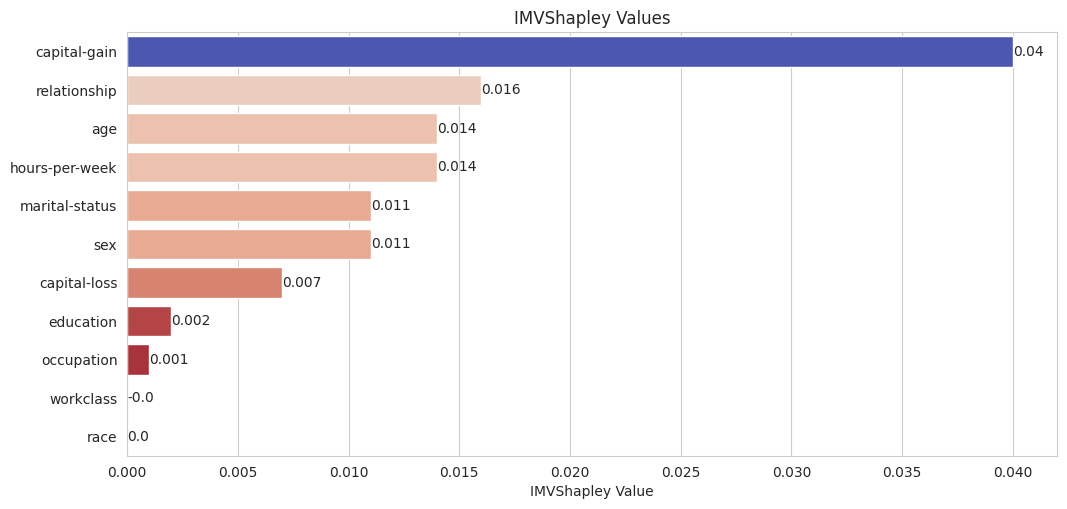

In [ ]:
from sklearn.linear_model import LogisticRegression

def create_logistic_regression_model():
    return LogisticRegression(max_iter=500, random_state=42)


evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_logistic_regression_model,
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=42
)
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()



Evaluating IMV combinations:   0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Best explanatory variables' combination: ('age', 'education', 'marital-status', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.12026507225128794
SHAP-IMV value for variable age: 0.014
SHAP-IMV value for variable workclass: 0.0
SHAP-IMV value for variable education: 0.002
SHAP-IMV value for variable marital-status: 0.01
SHAP-IMV value for variable occupation: 0.001
SHAP-IMV value for variable relationship: 0.016
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.011
SHAP-IMV value for variable capital-gain: 0.04
SHAP-IMV value for variable capital-loss: 0.007
SHAP-IMV value for variable hours-per-week: 0.014


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

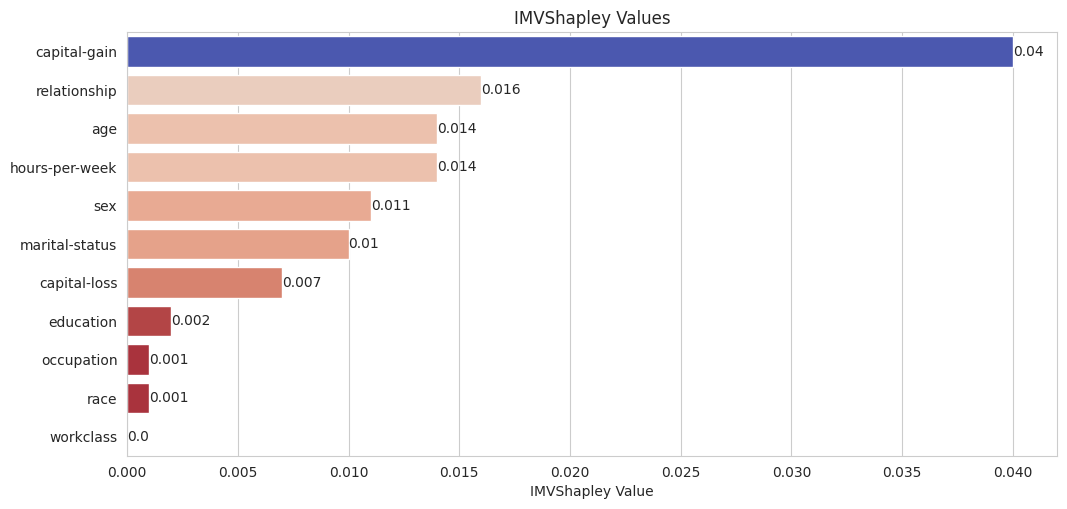

In [ ]:
from sklearn.linear_model import LogisticRegression

def create_logistic_regression_model():
    return LogisticRegression(max_iter=500, random_state=43)


evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_logistic_regression_model,
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=43
)
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()




Evaluating IMV combinations:   0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Evaluating IMV combinations:   0%|          | 0/2048 [39:02<?, ?it/s]


Best explanatory variables' combination: ('age', 'education', 'marital-status', 'relationship', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.1201595330654994
SHAP-IMV value for variable age: 0.014
SHAP-IMV value for variable workclass: -0.0
SHAP-IMV value for variable education: 0.002
SHAP-IMV value for variable marital-status: 0.01
SHAP-IMV value for variable occupation: 0.0
SHAP-IMV value for variable relationship: 0.016
SHAP-IMV value for variable race: 0.0
SHAP-IMV value for variable sex: 0.011
SHAP-IMV value for variable capital-gain: 0.04
SHAP-IMV value for variable capital-loss: 0.007
SHAP-IMV value for variable hours-per-week: 0.014


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

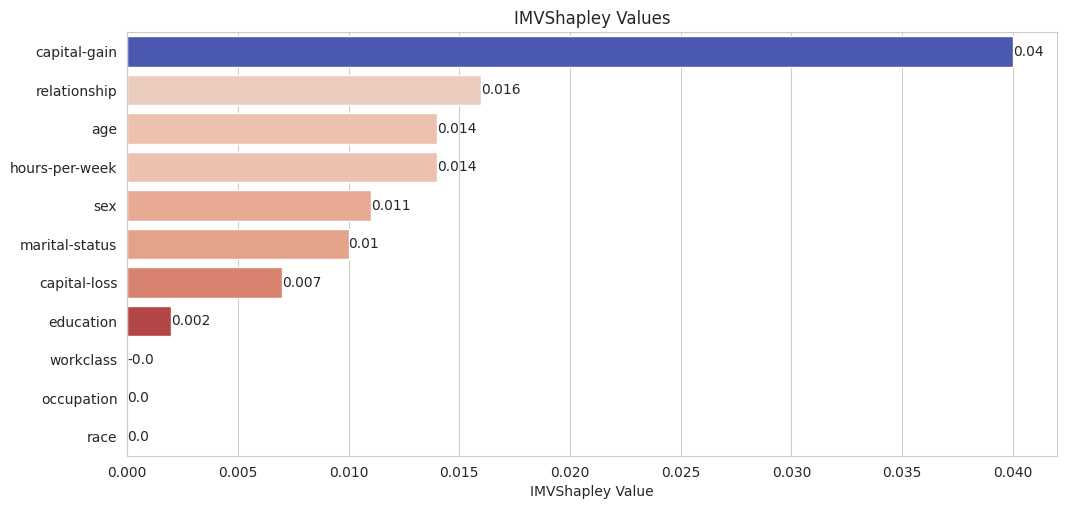

In [ ]:
from sklearn.linear_model import LogisticRegression

def create_logistic_regression_model():
    return LogisticRegression(max_iter=500, random_state=44)


evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_logistic_regression_model,
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=44
)
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()

## XGBoost

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, KFold
from itertools import combinations
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

class IMVEvaluator:
    def __init__(self, data, outcome_variable, optional_explanatory_variables, model_creator, split_method, n_splits, prop_test, model_type, all_combinations_imv=None, random_seed=42):
        self.data = data
        self.outcome_variable = outcome_variable
        self.optional_explanatory_variables = optional_explanatory_variables
        self.model_creator = model_creator
        self.split_method = split_method
        self.n_splits = n_splits
        self.prop_test = prop_test
        self.model_type = model_type
        self.random_seed = random_seed  # Set the random seed
        self.data['constant'] = 1  # Add a constant column for modeling
        self.all_combinations_imv = all_combinations_imv if all_combinations_imv is not None else {}

    @staticmethod
    def ll(x, p):
        epsilon = 1e-4
        z = (np.log(p + epsilon) * x) + (np.log(1 - p + epsilon) * (1 - x))
        return np.exp(np.sum(z) / len(z))

    @staticmethod
    def minimize_me(p, a):
        return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

    @classmethod
    def get_w(cls, a, guess=0.5, bounds=[(0.5, 0.999)]):
        res = minimize(cls.minimize_me, guess, args=(a,), options={'ftol': 0, 'gtol': 1e-09}, method='L-BFGS-B', bounds=bounds)
        return res.x[0]

    @classmethod
    def calculate_imv(cls, y_basic, y_enhanced, y):
        ll_basic = cls.ll(y, y_basic)
        ll_enhanced = cls.ll(y, y_enhanced)
        w0 = cls.get_w(ll_basic)
        w1 = cls.get_w(ll_enhanced)
        return (w1 - w0) / w0

    def calculate_imv_score(self, model_basic, model_enhanced, X_basic, X_enhanced, y):
        if self.model_type == 'classification':
            pred_basic = model_basic.predict_proba(X_basic)[:, 1]
            pred_enhanced = model_enhanced.predict_proba(X_enhanced)[:, 1]
        elif self.model_type == 'regression':
            pred_basic = model_basic.predict(X_basic)
            pred_enhanced = model_enhanced.predict(X_enhanced)
        else:
            raise ValueError("model_type must be 'classification' or 'regression'")
        return self.calculate_imv(pred_basic, pred_enhanced, y)

    def compute_imv_method(self, combination):
        X = self.data[list(combination) + ['constant']]
        y = self.data[self.outcome_variable]
        imv_scores = []
        fold_imv_scores = []

        if self.split_method == 'train_test_split':
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.prop_test, random_state=self.random_seed)
            model_basic = self.model_creator()
            model_enhanced = self.model_creator()
            model_basic.fit(X_train[['constant']], y_train)
            model_enhanced.fit(X_train, y_train)
            imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
            imv_scores.append(imv_score)
            fold_imv_scores.append(imv_score)
        elif self.split_method == 'kfold':
            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_seed)
            for train_index, test_index in kf.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
                model_basic = self.model_creator()
                model_enhanced = self.model_creator()
                model_basic.fit(X_train[['constant']], y_train)
                model_enhanced.fit(X_train, y_train)
                imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
                imv_scores.append(imv_score)
                fold_imv_scores.append(imv_score)
        return (tuple(combination), np.mean(imv_scores), fold_imv_scores)

    def run_evaluation(self):
      combinations_list = [
          subset
          for L in range(0, len(self.optional_explanatory_variables) + 1)
          for subset in combinations(self.optional_explanatory_variables, L)]

      results = {}

      # Use joblib's Parallel and delayed for parallel computation with tqdm
      with tqdm_joblib(tqdm(desc="Evaluating IMV combinations", total=len(combinations_list)), leave=False):
        parallel_results = Parallel(n_jobs=-1)(
            delayed(self.compute_imv_method)(subset) for subset in combinations_list)

      for result in parallel_results:
        results[result[0]] = (result[1], result[2])

      self.all_combinations_imv = results
      best_combination, (max_imv, best_fold_scores) = max(self.all_combinations_imv.items(), key=lambda item: item[1][0])
      print(f"Best explanatory variables' combination: {best_combination}, with the highest IMV score: {max_imv}")


    @staticmethod
    def calculate_weight(s_size, n):
        return factorial(s_size) * factorial(n - s_size - 1) / factorial(n)

    def calculate_imvshapley_value(self, variable):
        n = max(len(combination) for combination in self.all_combinations_imv.keys())
        imvshapley_value = 0.0
        for combination, (imv_score, _) in self.all_combinations_imv.items():
            if variable in combination:
                subset = tuple(x for x in combination if x != variable)
                subset_imv = self.all_combinations_imv.get(subset, (0.0, []))[0]
                s_size = len(subset)
                weight = self.calculate_weight(s_size, n)
                marginal_contribution = imv_score - subset_imv
                imvshapley_value += weight * marginal_contribution
        imvshapley_value = round(imvshapley_value, 3)
        print(f"SHAP-IMV value for variable {variable}: {imvshapley_value}")
        return imvshapley_value


    def evaluate_imvshapley(self, ax=None, figsize=(12, 4)):
        imvshapley_values = {}
        for variable in self.optional_explanatory_variables:
            imvshapley_values[variable] = self.calculate_imvshapley_value(variable)

        sorted_keys = [k for k, v in sorted(imvshapley_values.items(), key=lambda item: item[1], reverse=True)]
        sorted_values = [round(imvshapley_values[k], 4) for k in sorted_keys]

        n_bars = len(sorted_keys)
        total_height_in = max(figsize[1], n_bars * 0.5)

        if ax is None:
            fig, ax = plt.subplots(figsize=(figsize[0], total_height_in))
            created_ax = True
        else:
            created_ax = False

        sns.set_style("whitegrid")


        norm = plt.Normalize(min(sorted_values), max(sorted_values))
        cmap = plt.get_cmap("coolwarm_r")
        colors = cmap(norm(sorted_values))

        sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)

        for index, value in enumerate(sorted_values):
            ax.text(value, index, str(value), va='center')

        ax.set_xlabel('IMVShapley Value')
        ax.set_title('IMVShapley Values')

        if created_ax:
          return fig, ax

        return ax



Evaluating IMV combinations:   0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Evaluating IMV combinations:   0%|          | 0/2048 [40:05<?, ?it/s]


Best explanatory variables' combination: ('age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.21493626848985792
SHAP-IMV value for variable age: 0.02
SHAP-IMV value for variable workclass: 0.004
SHAP-IMV value for variable education: 0.024
SHAP-IMV value for variable marital-status: 0.031
SHAP-IMV value for variable occupation: 0.021
SHAP-IMV value for variable relationship: 0.033
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.007
SHAP-IMV value for variable capital-gain: 0.045
SHAP-IMV value for variable capital-loss: 0.018
SHAP-IMV value for variable hours-per-week: 0.011


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

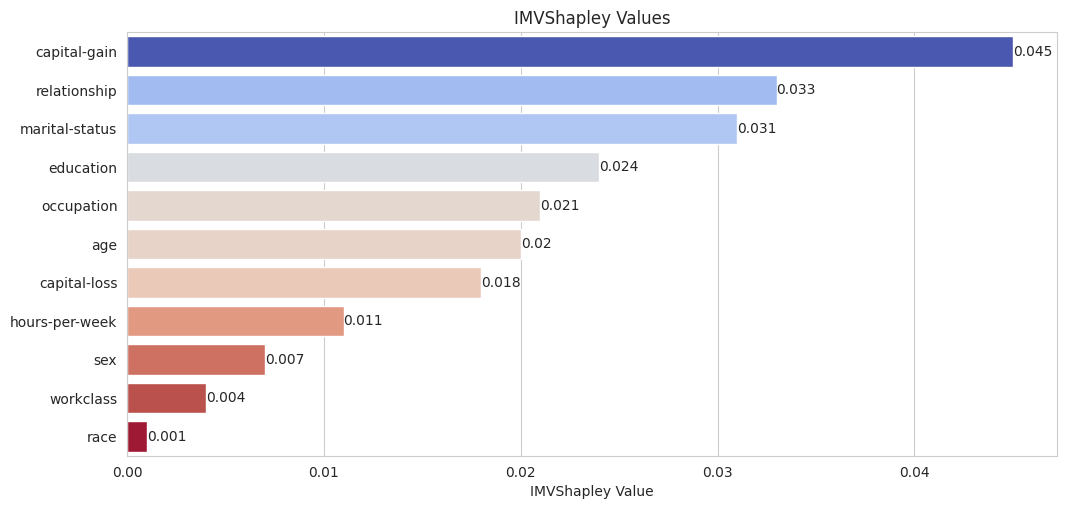

In [ ]:
from xgboost import XGBClassifier

# Function to create an XGBoost model
def create_xgb_model():
    return XGBClassifier(eval_metric='logloss', random_state=42)

# Use the updated function in your evaluator
evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_xgb_model,  # Use the new XGBClassifier function
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=42
)

# Run evaluation with the XGBoost model
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()




Evaluating IMV combinations:   0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Evaluating IMV combinations:   0%|          | 0/2048 [39:35<?, ?it/s]


Best explanatory variables' combination: ('age', 'workclass', 'education', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.21483697010440134
SHAP-IMV value for variable age: 0.02
SHAP-IMV value for variable workclass: 0.004
SHAP-IMV value for variable education: 0.024
SHAP-IMV value for variable marital-status: 0.031
SHAP-IMV value for variable occupation: 0.021
SHAP-IMV value for variable relationship: 0.033
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.007
SHAP-IMV value for variable capital-gain: 0.044
SHAP-IMV value for variable capital-loss: 0.018
SHAP-IMV value for variable hours-per-week: 0.011


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

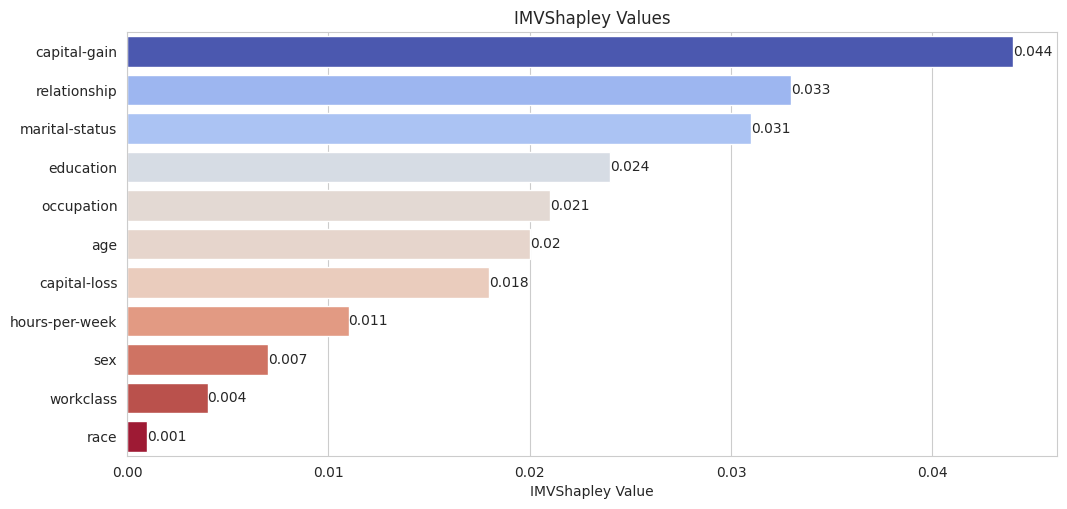

In [ ]:
from xgboost import XGBClassifier

# Function to create an XGBoost model
def create_xgb_model():
    return XGBClassifier(eval_metric='logloss', random_state=43)

# Use the updated function in your evaluator
evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_xgb_model,  # Use the new XGBClassifier function
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=43
)

# Run evaluation with the XGBoost model
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()



Evaluating IMV combinations:   0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Evaluating IMV combinations:   0%|          | 0/2048 [44:11<?, ?it/s]


Best explanatory variables' combination: ('age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.21481530031357385
SHAP-IMV value for variable age: 0.02
SHAP-IMV value for variable workclass: 0.004
SHAP-IMV value for variable education: 0.024
SHAP-IMV value for variable marital-status: 0.031
SHAP-IMV value for variable occupation: 0.021
SHAP-IMV value for variable relationship: 0.033
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.007
SHAP-IMV value for variable capital-gain: 0.045
SHAP-IMV value for variable capital-loss: 0.018
SHAP-IMV value for variable hours-per-week: 0.011


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

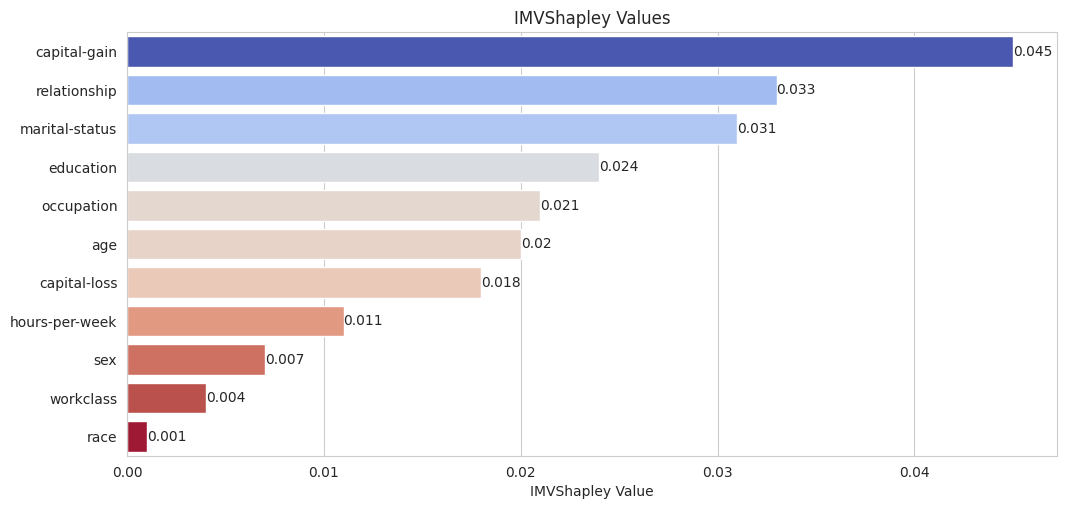

In [ ]:
from xgboost import XGBClassifier

# Function to create an XGBoost model
def create_xgb_model():
    return XGBClassifier(eval_metric='logloss', random_state=44)

# Use the updated function in your evaluator
evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_xgb_model,  # Use the new XGBClassifier function
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=44
)

# Run evaluation with the XGBoost model
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()

## LightGBM

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, KFold
from itertools import combinations
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from math import factorial

class IMVEvaluator:
    def __init__(self, data, outcome_variable, optional_explanatory_variables, model_creator, split_method, n_splits, prop_test, model_type, all_combinations_imv=None, random_seed=42):
        self.data = data
        self.outcome_variable = outcome_variable
        self.optional_explanatory_variables = optional_explanatory_variables
        self.model_creator = model_creator
        self.split_method = split_method
        self.n_splits = n_splits
        self.prop_test = prop_test
        self.model_type = model_type
        self.random_seed = random_seed  # Set the random seed
        self.data['constant'] = 1  # Add a constant column for modeling
        self.all_combinations_imv = all_combinations_imv if all_combinations_imv is not None else {}

    @staticmethod
    def ll(x, p):
        epsilon = 1e-4
        z = (np.log(p + epsilon) * x) + (np.log(1 - p + epsilon) * (1 - x))
        return np.exp(np.sum(z) / len(z))

    @staticmethod
    def minimize_me(p, a):
        return abs((p * np.log(p)) + ((1 - p) * np.log(1 - p)) - np.log(a))

    @classmethod
    def get_w(cls, a, guess=0.5, bounds=[(0.5, 0.999)]):
        res = minimize(cls.minimize_me, guess, args=(a,), options={'ftol': 0, 'gtol': 1e-09}, method='L-BFGS-B', bounds=bounds)
        return res.x[0]

    @classmethod
    def calculate_imv(cls, y_basic, y_enhanced, y):
        ll_basic = cls.ll(y, y_basic)
        ll_enhanced = cls.ll(y, y_enhanced)
        w0 = cls.get_w(ll_basic)
        w1 = cls.get_w(ll_enhanced)
        return (w1 - w0) / w0

    def calculate_imv_score(self, model_basic, model_enhanced, X_basic, X_enhanced, y):
        if self.model_type == 'classification':
            pred_basic = model_basic.predict_proba(X_basic)[:, 1]
            pred_enhanced = model_enhanced.predict_proba(X_enhanced)[:, 1]
        elif self.model_type == 'regression':
            pred_basic = model_basic.predict(X_basic)
            pred_enhanced = model_enhanced.predict(X_enhanced)
        else:
            raise ValueError("model_type must be 'classification' or 'regression'")
        return self.calculate_imv(pred_basic, pred_enhanced, y)

    def compute_imv_method(self, combination):
        X = self.data[list(combination) + ['constant']]
        y = self.data[self.outcome_variable]
        imv_scores = []
        fold_imv_scores = []

        if self.split_method == 'train_test_split':
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=self.prop_test, random_state=self.random_seed)
            model_basic = self.model_creator()
            model_enhanced = self.model_creator()
            model_basic.fit(X_train[['constant']], y_train)
            model_enhanced.fit(X_train, y_train)
            imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
            imv_scores.append(imv_score)
            fold_imv_scores.append(imv_score)
        elif self.split_method == 'kfold':
            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_seed)
            for train_index, test_index in kf.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]
                model_basic = self.model_creator()
                model_enhanced = self.model_creator()
                model_basic.fit(X_train[['constant']], y_train)
                model_enhanced.fit(X_train, y_train)
                imv_score = self.calculate_imv_score(model_basic, model_enhanced, X_test[['constant']], X_test, y_test)
                imv_scores.append(imv_score)
                fold_imv_scores.append(imv_score)
        return (tuple(combination), np.mean(imv_scores), fold_imv_scores)
    def run_evaluation(self):
        combinations_list = [
            subset
            for L in range(0, len(self.optional_explanatory_variables) + 1)
            for subset in combinations(self.optional_explanatory_variables, L)
        ]

        with tqdm_joblib(tqdm(total=len(combinations_list))) as progress_bar:
            results = Parallel(n_jobs=2)(
                delayed(self.compute_imv_method)(subset)
                for subset in combinations_list
            )

        self.all_combinations_imv = {combination: (imv_score, fold_scores) for combination, imv_score, fold_scores in results}
        best_combination, (max_imv, best_fold_scores) = max(self.all_combinations_imv.items(), key=lambda item: item[1][0])
        print(f"Best explanatory variables' combination: {best_combination}, with the highest IMV score: {max_imv}")


    @staticmethod
    def calculate_weight(s_size, n):
        return factorial(s_size) * factorial(n - s_size - 1) / factorial(n)

    def calculate_imvshapley_value(self, variable):
        n = max(len(combination) for combination in self.all_combinations_imv.keys())
        imvshapley_value = 0.0
        for combination, (imv_score, _) in self.all_combinations_imv.items():
            if variable in combination:
                subset = tuple(x for x in combination if x != variable)
                subset_imv = self.all_combinations_imv.get(subset, (0.0, []))[0]
                s_size = len(subset)
                weight = self.calculate_weight(s_size, n)
                marginal_contribution = imv_score - subset_imv
                imvshapley_value += weight * marginal_contribution
        imvshapley_value = round(imvshapley_value, 3)
        print(f"SHAP-IMV value for variable {variable}: {imvshapley_value}")
        return imvshapley_value


    def evaluate_imvshapley(self, ax=None, figsize=(12, 4)):
        imvshapley_values = {}
        for variable in self.optional_explanatory_variables:
            imvshapley_values[variable] = self.calculate_imvshapley_value(variable)

        sorted_keys = [k for k, v in sorted(imvshapley_values.items(), key=lambda item: item[1], reverse=True)]
        sorted_values = [round(imvshapley_values[k], 4) for k in sorted_keys]

        n_bars = len(sorted_keys)
        total_height_in = max(figsize[1], n_bars * 0.5)

        if ax is None:
            fig, ax = plt.subplots(figsize=(figsize[0], total_height_in))
            created_ax = True
        else:
            created_ax = False

        sns.set_style("whitegrid")


        norm = plt.Normalize(min(sorted_values), max(sorted_values))
        cmap = plt.get_cmap("coolwarm_r")
        colors = cmap(norm(sorted_values))

        sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)

        for index, value in enumerate(sorted_values):
            ax.text(value, index, str(value), va='center')

        ax.set_xlabel('IMVShapley Value')
        ax.set_title('IMVShapley Values')

        if created_ax:
          return fig, ax

        return ax

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/16 [18:38<?, ?it/s]


Best explanatory variables' combination: ('age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.21496632106518168
SHAP-IMV value for variable age: 0.021
SHAP-IMV value for variable workclass: 0.004
SHAP-IMV value for variable education: 0.024
SHAP-IMV value for variable marital-status: 0.032
SHAP-IMV value for variable occupation: 0.021
SHAP-IMV value for variable relationship: 0.033
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.007
SHAP-IMV value for variable capital-gain: 0.043
SHAP-IMV value for variable capital-loss: 0.017
SHAP-IMV value for variable hours-per-week: 0.012


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

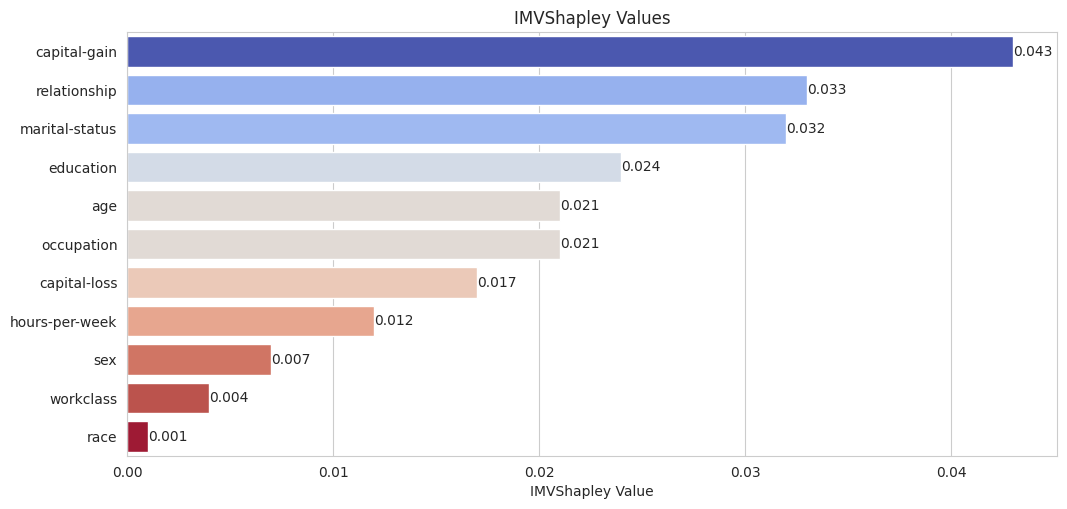

In [ ]:
from lightgbm import LGBMClassifier

# Function to create a LightGBM model
def create_lgb_model():
    return LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)

# Use the updated function in your evaluator
evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_lgb_model,  # Use the new LGBMClassifier function
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=42
)

# Run evaluation with the LightGBM model
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()

  0%|          | 0/2048 [59:46<?, ?it/s]


  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Best explanatory variables' combination: ('age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.21506226610366802
SHAP-IMV value for variable age: 0.021
SHAP-IMV value for variable workclass: 0.004
SHAP-IMV value for variable education: 0.024
SHAP-IMV value for variable marital-status: 0.032
SHAP-IMV value for variable occupation: 0.022
SHAP-IMV value for variable relationship: 0.033
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.007
SHAP-IMV value for variable capital-gain: 0.043
SHAP-IMV value for variable capital-loss: 0.017
SHAP-IMV value for variable hours-per-week: 0.012


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

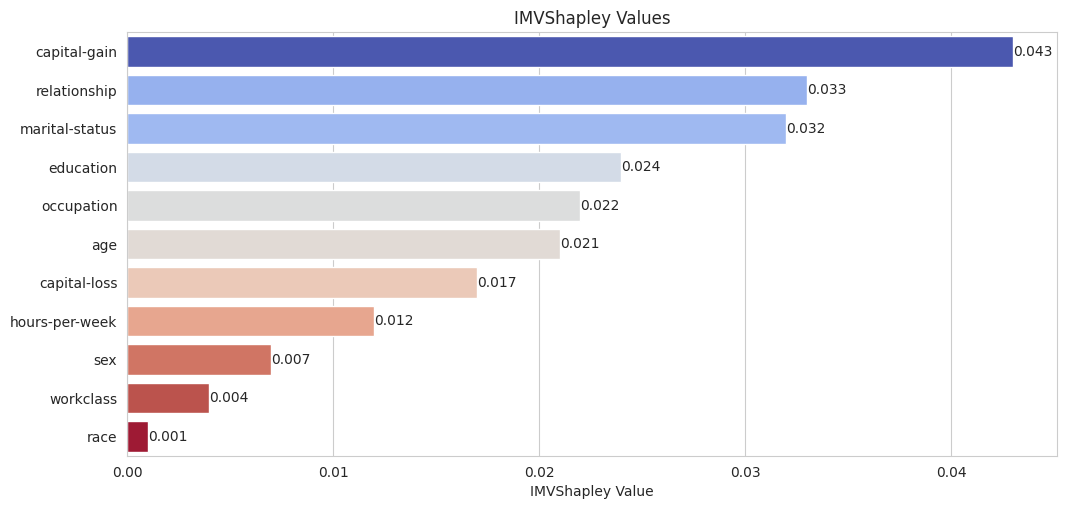

In [ ]:
from lightgbm import LGBMClassifier

# Function to create a LightGBM model
def create_lgb_model():
    return LGBMClassifier(n_estimators=100, random_state=43, verbosity=-1)

# Use the updated function in your evaluator
evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_lgb_model,  # Use the new LGBMClassifier function
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=43
)

# Run evaluation with the LightGBM model
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [1:06:59<?, ?it/s]


Best explanatory variables' combination: ('age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'), with the highest IMV score: 0.21510862188222762
SHAP-IMV value for variable age: 0.021
SHAP-IMV value for variable workclass: 0.004
SHAP-IMV value for variable education: 0.024
SHAP-IMV value for variable marital-status: 0.032
SHAP-IMV value for variable occupation: 0.021
SHAP-IMV value for variable relationship: 0.033
SHAP-IMV value for variable race: 0.001
SHAP-IMV value for variable sex: 0.007
SHAP-IMV value for variable capital-gain: 0.043
SHAP-IMV value for variable capital-loss: 0.017
SHAP-IMV value for variable hours-per-week: 0.011


(<Figure size 1200x550 with 1 Axes>,
 <Axes: title={'center': 'IMVShapley Values'}, xlabel='IMVShapley Value'>)

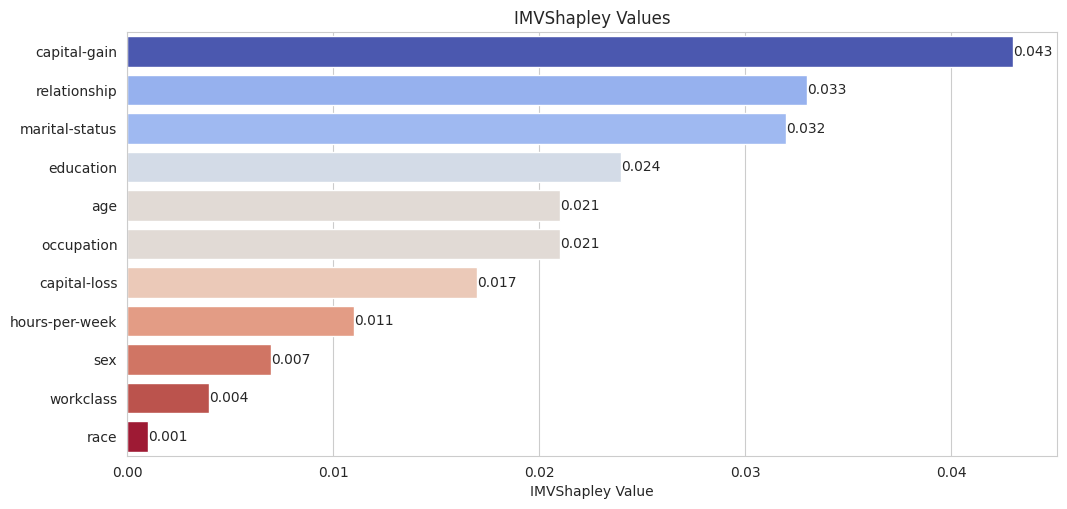

In [ ]:
from lightgbm import LGBMClassifier

# Function to create a LightGBM model
def create_lgb_model():
    return LGBMClassifier(n_estimators=100, random_state=44, verbosity=-1)

# Use the updated function in your evaluator
evaluator = IMVEvaluator(
    data=df_combined,
    outcome_variable='target',
    optional_explanatory_variables=['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'],
    model_creator=create_lgb_model,  # Use the new LGBMClassifier function
    split_method='kfold',
    n_splits=10,
    prop_test=0.2,
    model_type='classification',
    random_seed=44
)

# Run evaluation with the LightGBM model
evaluator.run_evaluation()
evaluator.evaluate_imvshapley()